In [ ]:
import json
import math

from staticmap3 import CircleMarker, StaticMap

In [ ]:
with open(
    "../dataset/mapqa/retrieval/california/train/train_socal_dpr_cased_entity.json", "r"
) as f:
    data = json.loads(f.read())

In [ ]:
pois = (
    data[0]["positive_ctxs"] + data[0]["negative_ctxs"] + data[0]["hard_negative_ctxs"]
)

In [60]:
coords = [(p["lat"], p["lng"]) for p in pois]

In [ ]:
def get_center(coords: list[tuple[float, float]]):
    (
        x,
        y,
        z,
    ) = 0.0, 0.0, 0.0
    for lat, lon in coords:
        lr, lo = math.radians(lat), math.radians(lon)
        x += math.cos(lr) * math.cos(lo)
        y += math.cos(lr) * math.sin(lo)
        z += math.sin(lr)

    n = len(coords)
    x, y, z = x / n, y / n, z / n
    lon = math.atan2(y, x)
    lat = math.atan2(z, math.sqrt(x**2 + y**2))

    return math.degrees(lat), math.degrees(lon)

In [77]:
get_center(coords)

(39.72326311853378, -113.92242605658552)

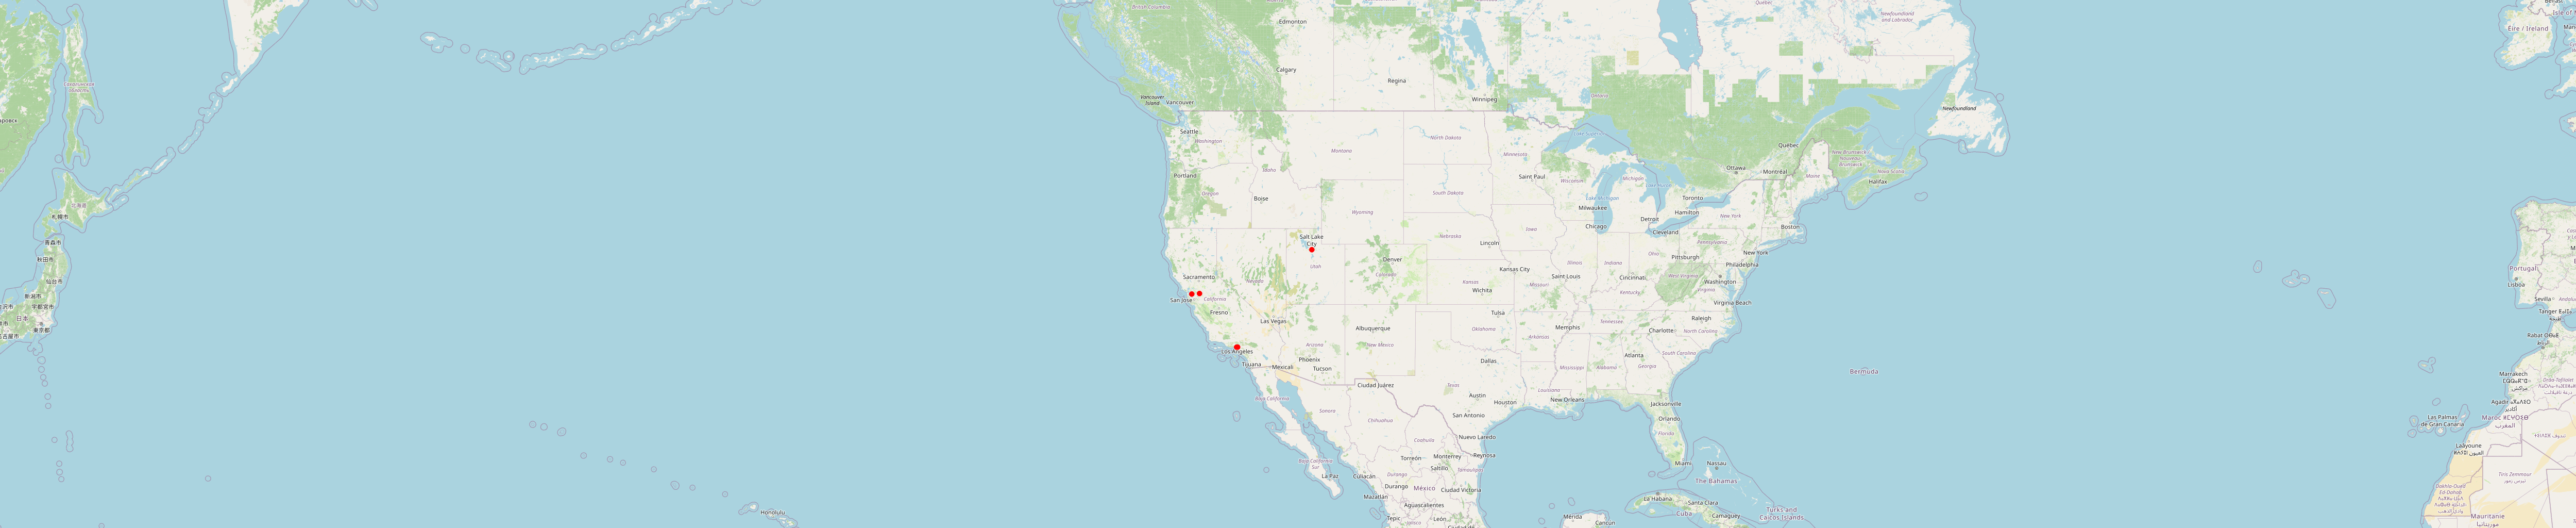

In [81]:
m = StaticMap(5000, 1024)
lat, lon = 34.07605439960424, -118.32399
lat, lon = get_center(coords)

# m.add_marker(CircleMarker((lon, lat), 'red', 12))
# m.add_marker(CircleMarker((-118.33, lat), 'blue', 12))

for c in coords:
    la, lo = c
    m.add_marker(CircleMarker((lo, la), color="red", width=10))

image = m.render(zoom=5, center=[lon, lat])
# image.save('map.png')
image

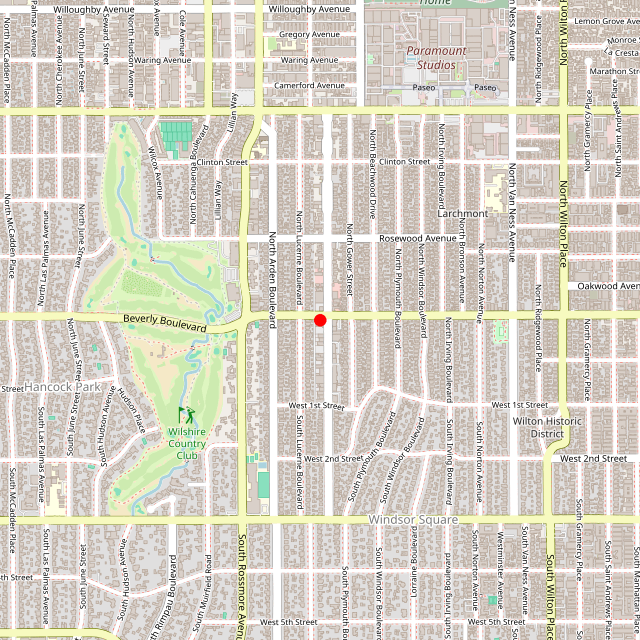

In [20]:
image

In [ ]:
import json

import polars as pl

In [ ]:
import requests


def get_amenity_overpass(osm_id):
    query = f"""                                                                                          
    [out:json];                                                                                             
    (
    node({osm_id});                                                                                       
    way({osm_id});                                                                                      
    relation({osm_id});                                                                                 
    );
    out tags;                                                                                               
    """
    resp = requests.post(
        "https://overpass-api.de/api/interpreter", data={"data": query}
    )
    elements = resp.json().get("elements", [])
    if elements:
        return elements[0].get("tags", {}).get("amenity")
    return None

In [239]:
import httpx

osm_id = "10895084940"

query = f"""                                                                                          
    [out:json];                                                                                             
    (
    node({osm_id});                                                                                       
    way({osm_id});                                                                                      
    relation({osm_id});                                                                                 
    );
    out bb;
    """
resp = httpx.post(
    "https://overpass-api.de/api/interpreter",
    data={"data": query},
    headers={"User-Agent": "mapqa-ext"},
)
resp.json()

{'version': 0.6,
 'generator': 'Overpass API 0.7.62.11 87bfad18',
 'osm3s': {'timestamp_osm_base': '2026-05-24T15:09:14Z',
  'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.'},
 'elements': []}

In [ ]:
url = "https://nominatim.openstreetmap.org/lookup"
params = {
    "osm_ids": f"N{osm_id}",
    "format": "json",
    "extratags": 1,
}
resp = httpx.get(url, params=params, headers={"User-Agent": "mapqa-ext"})
resp

<Response [200 OK]>

In [217]:
import json
import os
from typing import List

import httpx
from pydantic import BaseModel
from tqdm import tqdm
import time


class OSMPOI(BaseModel):
    osm_id: int
    lat: float
    lon: float
    poi_class: str
    poi_type: str
    name: str
    city: str | None
    country: str
    country_code: str
    bounding_box: List[float]

In [203]:
basepath = "../dataset/mapqa/llm/california_full/question-answer"

entities = []
for fname in tqdm(os.listdir(basepath), desc="processing files"):
    if fname.endswith(".csv"):
        continue

    with open(os.path.join(basepath, fname), "r") as f:
        data = json.loads(f.read())
        for dd in tqdm(data, desc=f"merging {fname}...", leave=True):
            for k, v in data[dd].items():
                ent = v
                ent["name"] = k
                ent["source"] = fname
                ent["question_id"] = dd
                entities.append(ent)

processing files: 100%|██████████| 18/18 [00:00<00:00, 941.02it/s]


In [228]:
df_qa = pl.DataFrame(entities)
df_qa

osm_id,latitude,longitude,name,source,question_id
i64,f64,f64,str,str,str
9742148508,34.043691,-118.446272,"""Hayama""","""adjacent_dataset.json""","""1"""
8356082493,34.043907,-118.445993,"""Plan Check""","""adjacent_dataset.json""","""1"""
4654147578,33.037508,-117.292826,"""Surfdog's Java Hot""","""adjacent_dataset.json""","""2"""
3744660951,33.037854,-117.29295,"""Union Kitchen & Tap""","""adjacent_dataset.json""","""2"""
5742849522,34.046758,-118.525466,"""Denise Carolyn""","""adjacent_dataset.json""","""3"""
…,…,…,…,…,…
8235924412,33.46992,-117.588373,"""Nob Hill""","""intersection_dataset.json""","""395"""
3281423161,32.892286,-117.207314,"""Goodwill""","""intersection_dataset.json""","""396"""
10936635285,33.940662,-118.139884,"""Law Office of Raymond Perez""","""intersection_dataset.json""","""397"""


In [229]:
osm_ids = df_qa.select("osm_id").unique().to_numpy().reshape(-1).tolist()

In [230]:
def osm_lookup(osm_ids: list[any], osm_type: str = "N") -> List[OSMPOI]:
    url = "https://nominatim.openstreetmap.org/lookup"
    batch = [f"{osm_type}{i}" for i in osm_ids]
    params = {
        "osm_ids": ",".join(batch),
        "format": "json",
        "addressdetails": 1,
        "extratags": 1,
        "namedetails": 1,
    }
    headers = {"User-Agent": "mapqa-ext"}

    res = httpx.get(url, params=params, headers=headers)
    return res.json()

In [231]:
pois = []
bs = 50
for i in tqdm(range(0, len(osm_ids), bs), desc="batch lookup"):
    batch = osm_ids[i : i + bs]
    res = osm_lookup(batch)

    for r in res:
        item = OSMPOI(
            osm_id=r["osm_id"],
            lat=r["lat"],
            lon=r["lon"],
            poi_class=r["class"],
            poi_type=r["type"],
            name=r["name"],
            city=r["address"].get("city")
            or r["address"].get("town")
            or r["address"].get("village"),
            country=r["address"]["country"],
            country_code=r["address"]["country_code"],
            bounding_box=[float(point) for point in r["boundingbox"]],
        )
        pois.append(item)

    time.sleep(1)

batch lookup: 100%|██████████| 48/48 [01:45<00:00,  2.19s/it]


In [232]:
len(osm_ids)

2391

In [233]:
pois_dict = [poi.model_dump() for poi in pois]
df_pois = pl.DataFrame(pois_dict)
df_pois

osm_id,lat,lon,poi_class,poi_type,name,city,country,country_code,bounding_box
i64,f64,f64,str,str,str,str,str,str,list[f64]
10301566273,34.028432,-118.480055,"""amenity""","""restaurant""","""Socalo""","""Santa Monica""","""United States""","""us""","[34.028382, 34.028482, … -118.480005]"
6112103476,35.329016,-120.688236,"""railway""","""spur_junction""","""CP CO244""",null,"""United States""","""us""","[35.328966, 35.329066, … -120.688186]"
274193511,32.82139,-117.183779,"""amenity""","""restaurant""","""Thai Time 3""","""San Diego""","""United States""","""us""","[32.82134, 32.82144, … -117.183729]"
11404844857,32.715887,-117.158761,"""amenity""","""bar""","""Time Out Sports Tavern""","""San Diego""","""United States""","""us""","[32.715837, 32.715937, … -117.158711]"
3417930443,32.880346,-117.236106,"""amenity""","""atm""","""Bank of America""","""San Diego""","""United States""","""us""","[32.880296, 32.880396, … -117.236056]"
…,…,…,…,…,…,…,…,…,…
348183510,34.395865,-118.922952,"""amenity""","""fuel""","""7-Eleven""","""Fillmore""","""United States""","""us""","[34.395815, 34.395915, … -118.922902]"
10775232967,35.335299,-119.036795,"""shop""","""shoes""","""Feet for Life""","""Bakersfield""","""United States""","""us""","[35.335249, 35.335349, … -119.036745]"
908207390,34.418229,-119.702794,"""highway""","""bus_stop""","""De la Vina & Canon Perdido""","""Santa Barbara""","""United States""","""us""","[34.418179, 34.418279, … -119.702744]"


In [ ]:
df_qa.join(df_pois, on="osm_id", how="left").write_json

osm_id,latitude,longitude,name,source,question_id,lat,lon,poi_class,poi_type,name_right,city,country,country_code,bounding_box
i64,f64,f64,str,str,str,f64,f64,str,str,str,str,str,str,list[f64]
9742148508,34.043691,-118.446272,"""Hayama""","""adjacent_dataset.json""","""1""",34.043692,-118.446271,"""amenity""","""restaurant""","""Hayama""","""Los Angeles""","""United States""","""us""","[34.043641, 34.043742, … -118.446221]"
8356082493,34.043907,-118.445993,"""Plan Check""","""adjacent_dataset.json""","""1""",34.043907,-118.445993,"""amenity""","""restaurant""","""Plan Check""","""Los Angeles""","""United States""","""us""","[34.043857, 34.043957, … -118.445943]"
4654147578,33.037508,-117.292826,"""Surfdog's Java Hot""","""adjacent_dataset.json""","""2""",33.037508,-117.292826,"""amenity""","""fast_food""","""Surfdog's Java Hot""","""Encinitas""","""United States""","""us""","[33.037458, 33.037558, … -117.292776]"
3744660951,33.037854,-117.29295,"""Union Kitchen & Tap""","""adjacent_dataset.json""","""2""",33.037854,-117.29295,"""amenity""","""restaurant""","""Union Kitchen & Tap""","""Encinitas""","""United States""","""us""","[33.037804, 33.037904, … -117.2929]"
5742849522,34.046758,-118.525466,"""Denise Carolyn""","""adjacent_dataset.json""","""3""",34.046758,-118.525466,"""shop""","""clothes""","""Denise Carolyn""","""Los Angeles""","""United States""","""us""","[34.046708, 34.046808, … -118.525416]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8235924412,33.46992,-117.588373,"""Nob Hill""","""intersection_dataset.json""","""395""",33.46992,-117.588373,"""amenity""","""binoculars""","""Nob Hill""","""San Clemente""","""United States""","""us""","[33.46987, 33.46997, … -117.588323]"
3281423161,32.892286,-117.207314,"""Goodwill""","""intersection_dataset.json""","""396""",32.892286,-117.207313,"""amenity""","""donation""","""Goodwill""","""San Diego""","""United States""","""us""","[32.892236, 32.892336, … -117.207263]"
10936635285,33.940662,-118.139884,"""Law Office of Raymond Perez""","""intersection_dataset.json""","""397""",33.940662,-118.139884,"""amenity""","""Attorneys""","""Law Office of Raymond Perez""","""Downey""","""United States""","""us""","[33.940612, 33.940712, … -118.139834]"


In [1]:
# try deployed overpass api
import httpx
from tqdm import tqdm
import sys
sys.path.append("..")
from src.schema.schema import OSMPOI

In [2]:
base_url = "http://100.69.181.117:4567/api/interpreter"

In [23]:
query = """
    [out:json][timeout:300];
    area["ISO3166-1"="VN"]->.country;
    (
    relation["boundary"="administrative"]
            ["admin_level"="6"]
            (area.country);
    );
    out center tags;
""".strip()

resp = httpx.get(
    base_url,
    params={"data": query},
    headers={"User-Agent": "mapqa-ext-notebook"},
    timeout=10,
)

In [56]:
query = """
    [out:json][timeout:120];
        area(3615689358)->.city;
        (
                node["amenity"](area.city);
    way["amenity"](area.city);
    relation["amenity"](area.city);
    node["shop"](area.city);
    way["shop"](area.city);
    relation["shop"](area.city);
    node["tourism"](area.city);
    way["tourism"](area.city);
    relation["tourism"](area.city);
    node["leisure"](area.city);
    way["leisure"](area.city);
    relation["leisure"](area.city);
    node["office"](area.city);
    way["office"](area.city);
    relation["office"](area.city);
    node["historic"](area.city);
    way["historic"](area.city);
    relation["historic"](area.city);

        );
        out bb tags;
""".strip()

resp = httpx.post(
    base_url,
    data={"data": query},
    headers={"User-Agent": "mapqa-ext-notebook"},
    timeout=60,
)
resp

<Response [200 OK]>

In [59]:
resp.json()

{'version': 0.6,
 'generator': 'Overpass API 0.7.62.11 87bfad18',
 'osm3s': {'timestamp_osm_base': '2026-06-01T20:20:56Z',
  'timestamp_areas_base': '2026-06-01T20:20:56Z',
  'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.'},
 'elements': []}

In [40]:
gc.get_countries()["SG"]

{'geonameid': 1880251,
 'name': 'Singapore',
 'iso': 'SG',
 'iso3': 'SGP',
 'isonumeric': 702,
 'fips': 'SN',
 'continentcode': 'AS',
 'capital': 'Singapore',
 'areakm2': 692,
 'population': 5638676,
 'tld': '.sg',
 'currencycode': 'SGD',
 'currencyname': 'Dollar',
 'phone': '65',
 'postalcoderegex': '^(\\d{6})$',
 'languages': 'cmn,en-SG,ms-SG,ta-SG,zh-SG',
 'neighbours': ''}

In [30]:
resp.json()

{'version': 0.6,
 'generator': 'Overpass API 0.7.62.11 87bfad18',
 'osm3s': {'timestamp_osm_base': '2026-06-01T20:20:56Z',
  'timestamp_areas_base': '2026-06-01T20:20:56Z',
  'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.'},
 'elements': [{'type': 'node',
   'id': 2824781385,
   'lat': -3.9972106,
   'lon': 122.5086495,
   'tags': {'amenity': 'place_of_worship',
    'building': 'mosque',
    'religion': 'muslim'}},
  {'type': 'node',
   'id': 2877618373,
   'lat': -3.9918915,
   'lon': 122.5130849,
   'tags': {'amenity': 'place_of_worship',
    'building': 'mosque',
    'religion': 'muslim'}},
  {'type': 'node',
   'id': 2877639938,
   'lat': -3.992455,
   'lon': 122.5084224,
   'tags': {'amenity': 'place_of_worship',
    'building': 'mosque',
    'name': 'Masjid Al-Khairat',
    'religion': 'muslim'}},
  {'type': 'node',
   'id': 2879718359,
   'lat': -3.9988865,
   'lon': 122.5204229,
   'tags': {'amenity': 'hosp

In [ ]:
# query by bounding boxes
BBOX = "(-6.3726,106.6890,-6.0813,107.0048)"
POI_CLASSES = ["amenity", "shop", "tourism", "leisure", "office", "historic"]

query = f"""
[out:json][timeout:300];
(
{"".join(f'    {elem}["{cls}"]{BBOX};' + chr(10) for cls in POI_CLASSES for elem in ["node", "way", "relation"])}
);
out bb tags;
""".strip()

In [ ]:
# query by city name
POI_CLASSES = ["amenity", "shop", "tourism", "leisure", "office", "historic"]

query = f"""
[out:json][timeout:300];
area["name"~"Jakarta"]["admin_level"="4"]->.city;
(
{"".join(f'    {elem}["{cls}"](area.city);' + chr(10) for cls in POI_CLASSES for elem in ["node", "way", "relation"])}
);
out bb tags;
""".strip()

In [123]:
query = """/* run_999 */
[out:json][timeout:300][rate-limit:1];
        area["name"~"Singapore"]["admin_level"~"4|5|6"]->.city;
        (
                node["amenity"](area.city);
    way["amenity"](area.city);
    relation["amenity"](area.city);
    node["shop"](area.city);
    way["shop"](area.city);
    relation["shop"](area.city);
    node["tourism"](area.city);
    way["tourism"](area.city);
    relation["tourism"](area.city);
    node["leisure"](area.city);
    way["leisure"](area.city);
    relation["leisure"](area.city);
    node["office"](area.city);
    way["office"](area.city);
    relation["office"](area.city);
    node["historic"](area.city);
    way["historic"](area.city);
    relation["historic"](area.city);

        );
        out bb tags;""".strip()

print(query)

/* run_999 */
[out:json][timeout:300][rate-limit:1];
        area["name"~"Singapore"]["admin_level"~"4|5|6"]->.city;
        (
                node["amenity"](area.city);
    way["amenity"](area.city);
    relation["amenity"](area.city);
    node["shop"](area.city);
    way["shop"](area.city);
    relation["shop"](area.city);
    node["tourism"](area.city);
    way["tourism"](area.city);
    relation["tourism"](area.city);
    node["leisure"](area.city);
    way["leisure"](area.city);
    relation["leisure"](area.city);
    node["office"](area.city);
    way["office"](area.city);
    relation["office"](area.city);
    node["historic"](area.city);
    way["historic"](area.city);
    relation["historic"](area.city);

        );
        out bb tags;


In [125]:
resp = httpx.get(
    base_url,
    params={"data": query},
    headers={"User-Agent": "mapqa-ext-notebook"},
    timeout=10,
)
raw_elements = resp.json().get("elements", [])
print(f"Total raw elements: {len(raw_elements)}")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [122]:
print(resp.content.decode())

<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">
<head>
  <meta http-equiv="content-type" content="text/html; charset=utf-8" lang="en"/>
  <title>OSM3S Response</title>
</head>
<body>

<p>The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.</p>
<p><strong style="color:#FF0000">Error</strong>: runtime error: open64: 0 Success /osm3s_osm_base Dispatcher_Client::request_read_and_idx::duplicate_query </p>

</body>
</html>



In [110]:
import json

with open("../dataset/cities.json", "r") as f:
    data = json.loads(f.read())

In [117]:
[d["name"] for d in data if d["country"] == "Singapore"]

['Singapore']

In [88]:
def parse_element(elem: dict) -> OSMPOI | None:
    tags = elem.get("tags", {})

    poi_class, poi_type = None, None
    for cls in POI_CLASSES:
        if cls in tags:
            poi_class, poi_type = cls, tags[cls]
            break
    if not poi_class:
        return None

    if elem["type"] == "node":
        lat, lon = elem["lat"], elem["lon"]
        bbox = [lat, lon, lat, lon]
    else:
        b = elem.get("bounds", {})
        bbox = [b.get("minlat"), b.get("minlon"), b.get("maxlat"), b.get("maxlon")]
        lat = (bbox[0] + bbox[2]) / 2 if bbox[0] is not None else None
        lon = (bbox[1] + bbox[3]) / 2 if bbox[1] is not None else None

    return OSMPOI(
        osm_id=elem["id"],
        lat=lat,
        lon=lon,
        poi_class=poi_class,
        poi_type=poi_type,
        name=tags.get("name", ""),
        city=tags.get("addr:city") or tags.get("addr:district"),
        country=tags.get("addr:country", "Indonesia"),
        country_code=tags.get("addr:country_code", "id"),
        bounding_box=bbox,
    )


pois = [p for elem in raw_elements if (p := parse_element(elem)) is not None]
print(f"Parsed POIs: {len(pois)}")
pois[0]

Parsed POIs: 38842


OSMPOI(osm_id=29897893, lat=-5.7002292, lon=106.5367392, poi_class='tourism', poi_type='hotel', name='Alam Kotok - Island Resort', city=None, country='Indonesia', country_code='id', bounding_box=[-5.7002292, 106.5367392, -5.7002292, 106.5367392])